In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()print(df.info())

print(df.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

In [8]:
X = df[['AveRooms']].values

y = df['MedHouseVal'].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
theta0 = 0
theta1 = 0

learning_rate = 0.001
epochs = 2000

n = len(X_train)

for i in range(epochs):

    y_pred = theta0 + theta1 * X_train.flatten()

    d_theta0 = (-2/n) * np.sum(y_train - y_pred)
    d_theta1 = (-2/n) * np.sum(X_train.flatten() * (y_train - y_pred))

    theta0 = theta0 - learning_rate * d_theta0
    theta1 = theta1 - learning_rate * d_theta1

print("Intercept =", theta0)
print("Slope =", theta1)

Intercept = 0.8019034431538502
Slope = 0.20888459942550064


In [12]:
y_pred_gd = theta0 + theta1 * X_test.flatten()

In [13]:
X_train_ne = np.c_[np.ones((len(X_train),1)), X_train]

theta = np.linalg.inv(
    X_train_ne.T.dot(X_train_ne)
).dot(
    X_train_ne.T
).dot(y_train)

print(theta)

[1.65476227 0.07675559]


In [14]:
X_test_ne = np.c_[np.ones((len(X_test),1)), X_test]

y_pred_ne = X_test_ne.dot(theta)

In [15]:
mse_gd = mean_squared_error(y_test, y_pred_gd)

r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent")

print("MSE =", mse_gd)

print("R2 =", r2_gd)

Gradient Descent
MSE = 1.4915941220541933
R2 = -0.13826610380563586


In [16]:
mse_ne = mean_squared_error(y_test, y_pred_ne)

r2_ne = r2_score(y_test, y_pred_ne)

print("Normal Equation")

print("MSE =", mse_ne)

print("R2 =", r2_ne)

Normal Equation
MSE = 1.2923314440807299
R2 = 0.013795337532284901


In [17]:
results = pd.DataFrame({

    "Method":[
        "Gradient Descent",
        "Normal Equation"
    ],

    "MSE":[
        mse_gd,
        mse_ne
    ],

    "R2 Score":[
        r2_gd,
        r2_ne
    ]

})

results

,Method,MSE,R2 Score
0,Gradient Descent,1.491594,-0.138266
1,Normal Equation,1.292331,0.013795


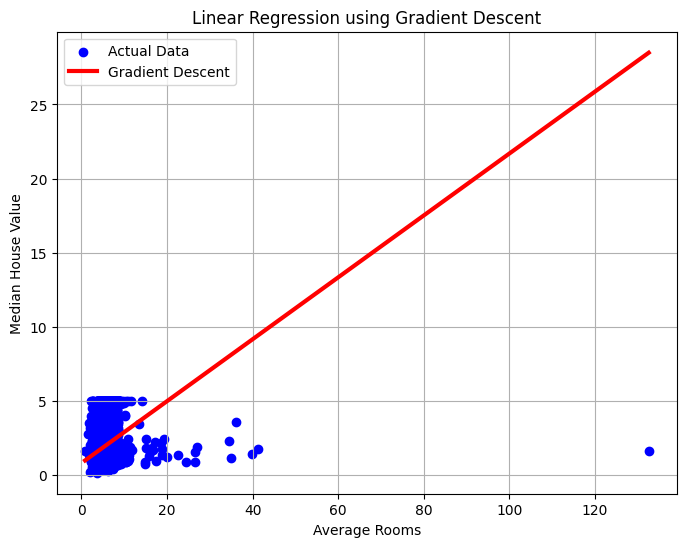

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')

x_line = np.linspace(X_test.min(), X_test.max(),100)

y_line = theta0 + theta1 * x_line

plt.plot(x_line,y_line,color='red',linewidth=3,label='Gradient Descent')

plt.xlabel("Average Rooms")

plt.ylabel("Median House Value")

plt.title("Linear Regression using Gradient Descent")

plt.legend()

plt.grid(True)

plt.show()

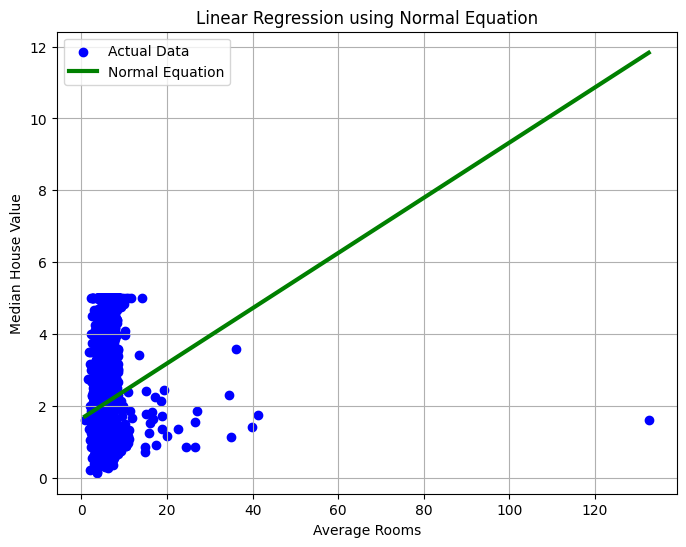

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(X_test,y_test,color='blue',label='Actual Data')

x_line=np.linspace(X_test.min(),X_test.max(),100)

y_line=theta[0]+theta[1]*x_line

plt.plot(x_line,y_line,color='green',linewidth=3,label='Normal Equation')

plt.xlabel("Average Rooms")

plt.ylabel("Median House Value")

plt.title("Linear Regression using Normal Equation")

plt.legend()

plt.grid(True)

plt.show()